In [1]:
# Import libraries
import pandas as pd

# ML tools
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_score, recall_score

In [2]:
# ----------------
# 1. LOAD DATASET 
# ----------------
df = pd.read_csv("spam.csv", encoding='latin-1')

# Keep only needed columns
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# Convert labels: ham=0, spam=1
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

In [3]:
# --------------------
# 2. TRAIN-TEST SPLIT
# --------------------
X = df['message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
# ----------
# 3. TF-IDF
# ----------
vectorizer = TfidfVectorizer(stop_words='english')

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [5]:
# ----------
# 4. MODELS
# ----------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC(kernel='linear')
}

In [6]:

# --------------------
# 5. TRAIN + EVALUATE
# --------------------
results = []

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    print(f"\n* {name}")
    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print("Precision:", prec)
    print("Recall:", rec)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    results.append([name, acc, f1, prec, rec])


* Logistic Regression
Accuracy: 0.9524663677130045
F1 Score: 0.7905138339920948
Precision: 0.970873786407767
Recall: 0.6666666666666666
Confusion Matrix:
 [[962   3]
 [ 50 100]]

* Random Forest
Accuracy: 0.9757847533632287
F1 Score: 0.9025270758122743
Precision: 0.984251968503937
Recall: 0.8333333333333334
Confusion Matrix:
 [[963   2]
 [ 25 125]]

* SVM
Accuracy: 0.979372197309417
F1 Score: 0.9192982456140351
Precision: 0.9703703703703703
Recall: 0.8733333333333333
Confusion Matrix:
 [[961   4]
 [ 19 131]]


In [7]:

# -----------------------------
# 6. COMPARISON TABLE
# -----------------------------
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1 Score", "Precision", "Recall"])
print("\nModel Comparison:\n")
print(results_df)


Model Comparison:

                 Model  Accuracy  F1 Score  Precision    Recall
0  Logistic Regression  0.952466  0.790514   0.970874  0.666667
1        Random Forest  0.975785  0.902527   0.984252  0.833333
2                  SVM  0.979372  0.919298   0.970370  0.873333


In [8]:

# -----------------------------
# 7. BEST MODEL
# -----------------------------
best_model_name = results_df.loc[results_df['Accuracy'].idxmax(), "Model"]
print("\nBest Model:", best_model_name)

best_model = models[best_model_name]


Best Model: SVM


In [9]:

# -----------------------------
# 8. CUSTOM INPUT TEST
# -----------------------------
sample = ["URGENT! You have won $1000 cash prize. Call now!!!"]
sample_tfidf = vectorizer.transform(sample)

prediction = best_model.predict(sample_tfidf)

print("\nPrediction:", "Spam" if prediction[0] == 1 else "Ham")


Prediction: Spam


In [12]:
sample = ["Hey, are we still meeting for lunch today?"]
sample_tfidf = vectorizer.transform(sample)

prediction = best_model.predict(sample_tfidf)

print("\nPrediction:", "Spam" if prediction[0] == 1 else "Ham")


Prediction: Ham


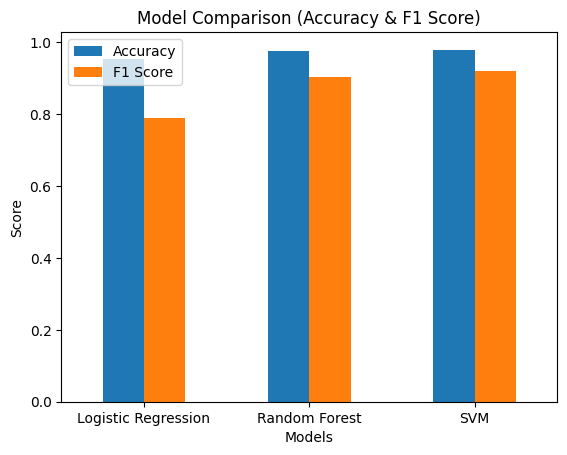

In [10]:
import matplotlib.pyplot as plt

# Set model as index
results_df.set_index("Model", inplace=True)

# Plot only important metrics
results_df[["Accuracy", "F1 Score"]].plot(kind='bar')

# Labels
plt.title("Model Comparison (Accuracy & F1 Score)")
plt.xlabel("Models")
plt.ylabel("Score")

# Keep names straight
plt.xticks(rotation=0)

# Show graph
plt.show()

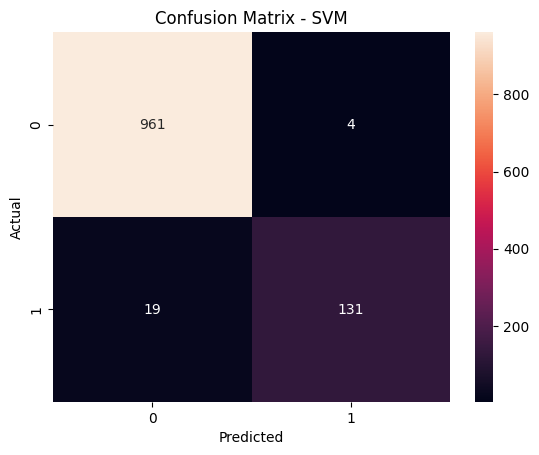

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Re-train SVM (ensure correct predictions)
svm_model = SVC(kernel='linear')
svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

# Plot heatmap
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()